# Exploratory Analysis — Student Academic Performance

This notebook is the **data inspection that preceded the modelling**. Everything
decided here shaped `src/train_models.py`, so it is worth reading first.

Three findings came out of it, and each one changed a design decision:

1. **38 students recorded a final grade of exactly 0** — almost certainly dropout
   or a missed exam, not a genuine score. Decision: keep them, and say so.
2. **`absences` correlates with the final grade at only r = +0.034 overall** —
   but that figure is an artefact. Remove the 38 zero-grade students and it
   becomes **r = −0.213**. Decision: report both numbers, because the headline
   one is misleading.
3. **The majority-class baseline scores 67.1% accuracy** while finding zero
   at-risk students. Decision: rank models by F1, not accuracy, and print the
   baseline in every comparison table.

It also confirms the leakage problem: `G1` and `G2` correlate +0.80 and +0.90
with `G3`, which is why they are excluded from every model in the project.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config as cfg
import data_preprocessing as dp

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("project root:", PROJECT_ROOT)

project root: /home/user/ML_MiniProj


## 2. Load the data and verify it against the published specification

`load_raw()` checks the file's shape against the 395 x 33 that UCI documents and
raises if it does not match. Training on a truncated or substituted download
would silently change every result in the project, so the check is worth having.

In [2]:
df_raw = dp.load_raw("mat")
print("shape:", df_raw.shape, "(UCI documents 395 x 33)")
print("missing values:", int(df_raw.isna().sum().sum()))
print("duplicate rows:", int(df_raw.duplicated().sum()))
df_raw.head()

shape: (395, 33) (UCI documents 395 x 33)
missing values: 0
duplicate rows: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


### 2.1 Column types

In [3]:
numeric = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"NUMERIC ({len(numeric)}):\n  {numeric}\n")
print(f"CATEGORICAL ({len(categorical)}):\n  {categorical}")

NUMERIC (16):
  ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

CATEGORICAL (17):
  ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [4]:
# Every categorical column and its levels. None are high-cardinality, so
# one-hot encoding is cheap here (17 columns become 30).
for col in categorical:
    print(f"  {col:12s} n={df_raw[col].nunique()}  {sorted(df_raw[col].unique())}")

  school       n=2  ['GP', 'MS']
  sex          n=2  ['F', 'M']
  address      n=2  ['R', 'U']
  famsize      n=2  ['GT3', 'LE3']
  Pstatus      n=2  ['A', 'T']
  Mjob         n=5  ['at_home', 'health', 'other', 'services', 'teacher']
  Fjob         n=5  ['at_home', 'health', 'other', 'services', 'teacher']
  reason       n=4  ['course', 'home', 'other', 'reputation']
  guardian     n=3  ['father', 'mother', 'other']
  schoolsup    n=2  ['no', 'yes']
  famsup       n=2  ['no', 'yes']
  paid         n=2  ['no', 'yes']
  activities   n=2  ['no', 'yes']
  nursery      n=2  ['no', 'yes']
  higher       n=2  ['no', 'yes']
  internet     n=2  ['no', 'yes']
  romantic     n=2  ['no', 'yes']


## 3. The target variable

`G3` is the final-period grade on the Portuguese 0-20 scale.

In [5]:
print(df_raw["G3"].describe().to_string())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000


### 3.1 Finding 1 — the spike at zero

This is the most consequential thing in the dataset and it is invisible in
`describe()`. Look at the value counts.

In [6]:
counts = df_raw["G3"].value_counts().sort_index()
print(counts.to_string())
print()
n_zero = int((df_raw["G3"] == 0).sum())
lowest_nonzero = int(df_raw.loc[df_raw["G3"] > 0, "G3"].min())
print(f"{n_zero} students scored exactly 0 ({n_zero / len(df_raw) * 100:.1f}% of the cohort)")
print(f"The lowest NON-ZERO grade is {lowest_nonzero} -- so there is a gap at 1, 2, 3.")

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1

38 students scored exactly 0 (9.6% of the cohort)
The lowest NON-ZERO grade is 4 -- so there is a gap at 1, 2, 3.


In [7]:
# What did those students score in the earlier periods?
zeros = df_raw[df_raw["G3"] == 0]
print("Students with G3 == 0 -- their earlier grades:")
print(zeros[["G1", "G2", "G3", "absences", "failures"]].describe().loc[
    ["mean", "min", "max"]].round(2).to_string())
print()
print(f"Of the {len(zeros)} students with G3 == 0:")
print(f"  {int((zeros['G1'] > 0).sum())} had a NON-ZERO first-period grade")
print(f"  {int((zeros['G2'] == 0).sum())} also scored 0 in the second period")

Students with G3 == 0 -- their earlier grades:
         G1     G2   G3  absences  failures
mean   7.53   4.66  0.0       0.0      0.92
min    4.00   0.00  0.0       0.0      0.00
max   12.00  10.00  0.0       0.0      3.00

Of the 38 students with G3 == 0:
  38 had a NON-ZERO first-period grade
  13 also scored 0 in the second period


**Reading this.** Two facts together make the case close to conclusive:

- **All 38** of these students earned a **non-zero first-period grade** (`G1`
  between 4 and 12), so they were attending and being assessed.
- **All 38** record **exactly 0 absences.**

A student cannot simultaneously have zero absences and have failed to sit the
final assessment. The combination of "attended every session" and "scored zero"
is not a plausible academic record — it is an administrative placeholder for a
student who left the roll or whose final mark was never entered.

**Decision: keep these students.** Two reasons. They are precisely the students
an early-warning system exists to find — they are the most at-risk group in the
data. And dropping 10% of the cohort because it improves R² would be selective
exclusion of inconvenient observations.

**Consequence, recorded honestly:** the target distribution becomes bimodal, and
the regression model picks up a cluster of very large residuals. Both show up in
the results.

### 3.2 The at-risk label

In [8]:
df = dp.add_target(df_raw)

at_risk = df[cfg.CLASSIFICATION_TARGET]
n, n_risk = len(df), int(at_risk.sum())
print(f"Threshold: G3 < {cfg.AT_RISK_THRESHOLD} (the pass mark on the 0-20 scale)")
print()
print(f"  At Risk      {n_risk:3d}  ({n_risk / n * 100:.1f}%)")
print(f"  Not At Risk  {n - n_risk:3d}  ({(n - n_risk) / n * 100:.1f}%)")
print()
baseline = max(at_risk.mean(), 1 - at_risk.mean())
print(f"Finding 3 -- MAJORITY-CLASS BASELINE ACCURACY: {baseline:.4f}")
print()
print("A model that answers 'Not At Risk' for every single student would score")
print(f"{baseline * 100:.1f}% accuracy, with recall 0 and F1 0 on the at-risk class.")
print("That is why this project ranks models by F1, not accuracy, and prints")
print("this baseline in every comparison table.")

Threshold: G3 < 10 (the pass mark on the 0-20 scale)

  At Risk      130  (32.9%)
  Not At Risk  265  (67.1%)

Finding 3 -- MAJORITY-CLASS BASELINE ACCURACY: 0.6709

A model that answers 'Not At Risk' for every single student would score
67.1% accuracy, with recall 0 and F1 0 on the at-risk class.
That is why this project ranks models by F1, not accuracy, and prints
this baseline in every comparison table.


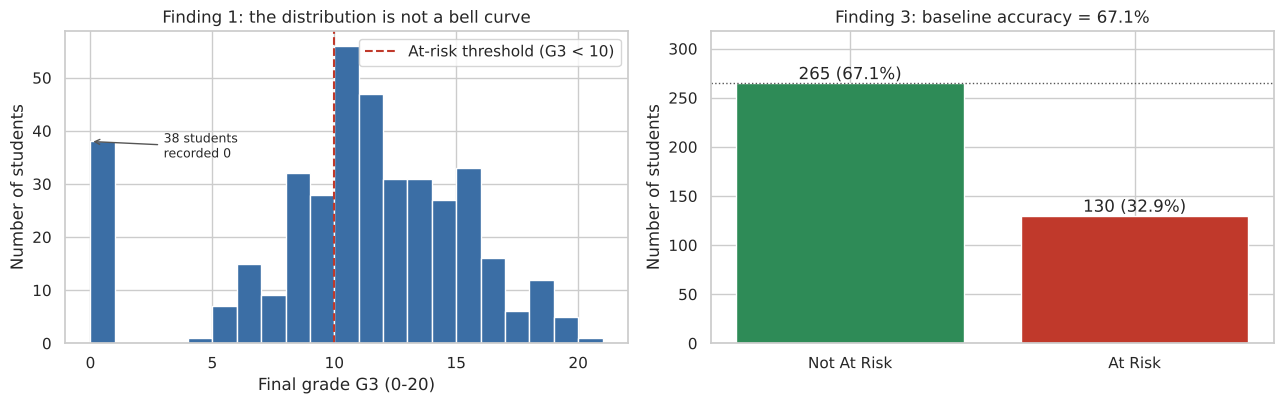

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(df["G3"], bins=21, range=(0, 21), edgecolor="white", color="#3b6ea5")
axes[0].axvline(cfg.AT_RISK_THRESHOLD, color="#c0392b", ls="--",
                label=f"At-risk threshold (G3 < {cfg.AT_RISK_THRESHOLD})")
axes[0].annotate(f"{n_zero} students\nrecorded 0", xy=(0, n_zero), xytext=(3, n_zero - 3),
                 arrowprops=dict(arrowstyle="->", color="#555"), fontsize=9)
axes[0].set_xlabel("Final grade G3 (0-20)")
axes[0].set_ylabel("Number of students")
axes[0].set_title("Finding 1: the distribution is not a bell curve")
axes[0].legend()

vals = [n - n_risk, n_risk]
axes[1].bar(["Not At Risk", "At Risk"], vals, color=["#2e8b57", "#c0392b"])
for i, v in enumerate(vals):
    axes[1].text(i, v + 4, f"{v} ({v / n * 100:.1f}%)", ha="center")
axes[1].axhline(n - n_risk, color="#555", ls=":", lw=1)
axes[1].set_ylabel("Number of students")
axes[1].set_title(f"Finding 3: baseline accuracy = {baseline:.1%}")
axes[1].set_ylim(0, max(vals) * 1.2)

plt.tight_layout(); plt.show()

## 4. Finding 2 — which features actually move with the final grade?

This is where the obvious expectation fails.

In [10]:
num_cols = cfg.NUMERIC_FEATURES + ["G1", "G2", "G3"]
corr_g3 = df[num_cols].corr(numeric_only=True)["G3"].drop("G3").sort_values()
print("Correlation with the final grade G3, weakest to strongest:")
print(corr_g3.to_string())

Correlation with the final grade G3, weakest to strongest:
failures     -0.360415
age          -0.161579
goout        -0.132791
traveltime   -0.117142
health       -0.061335
Dalc         -0.054660
Walc         -0.051939
freetime      0.011307
absences      0.034247
famrel        0.051363
studytime     0.097820
Fedu          0.152457
Medu          0.217147
G1            0.801468
G2            0.904868


In [11]:
usable = corr_g3.drop(["G1", "G2"])
print("Among features the models are ALLOWED to use, ranked by |r|:")
print(usable.reindex(usable.abs().sort_values(ascending=False).index).to_string())
print()
print(f"The strongest is `failures` at r = {usable['failures']:+.3f} -- a WEAK relationship.")
print(f"And `absences` is r = {usable['absences']:+.3f}, i.e. essentially nothing.")
print()
print("Finding 2: absences do NOT predict the final grade on this dataset.")
print("The project reports this rather than assuming the intuitive answer.")

Among features the models are ALLOWED to use, ranked by |r|:
failures     -0.360415
Medu          0.217147
age          -0.161579
Fedu          0.152457
goout        -0.132791
traveltime   -0.117142
studytime     0.097820
health       -0.061335
Dalc         -0.054660
Walc         -0.051939
famrel        0.051363
absences      0.034247
freetime      0.011307

The strongest is `failures` at r = -0.360 -- a WEAK relationship.
And `absences` is r = +0.034, i.e. essentially nothing.

Finding 2: absences do NOT predict the final grade on this dataset.
The project reports this rather than assuming the intuitive answer.


In [12]:
# Why is the overall absences correlation so flat? The zero-grade group is
# masking it -- and the way it does so is itself revealing.
mask = df["G3"] > 0
r_all = df["absences"].corr(df["G3"])
r_nonzero = df.loc[mask, "absences"].corr(df.loc[mask, "G3"])
print(f"r(absences, G3) over all 395 students        : {r_all:+.4f}")
print(f"r(absences, G3) excluding the 38 zero-grades : {r_nonzero:+.4f}")
print()
zeros_abs = df.loc[df["G3"] == 0, "absences"]
print(f"ALL {len(zeros_abs)} zero-grade students have absences == "
      f"{zeros_abs.min()}: {bool((zeros_abs == 0).all())}")
print(f"And all {len(zeros_abs)} of them have a NON-ZERO G1 "
      f"(range {int(df.loc[df['G3'] == 0, 'G1'].min())}"
      f"-{int(df.loc[df['G3'] == 0, 'G1'].max())}).")
print()
print("So the correlation does NOT stay flat -- it flips sign and grows sixfold,")
print(f"from {r_all:+.3f} to {r_nonzero:+.3f}, once the zero-grade group is removed.")

r(absences, G3) over all 395 students        : +0.0342
r(absences, G3) excluding the 38 zero-grades : -0.2131

ALL 38 zero-grade students have absences == 0: True
And all 38 of them have a NON-ZERO G1 (range 4-12).

So the correlation does NOT stay flat -- it flips sign and grows sixfold,
from +0.034 to -0.213, once the zero-grade group is removed.


### 4.1 The leakage problem, visible

In [13]:
print(f"r(G1, G3) = {df['G1'].corr(df['G3']):+.4f}")
print(f"r(G2, G3) = {df['G2'].corr(df['G3']):+.4f}")
print()
print("These are the first- and second-period grades. They are not background")
print("information about a student -- they are earlier measurements of the very")
print("outcome being predicted. Both are EXCLUDED from every model in this project.")
print()
print("Excluded columns and why:")
for col, reason in cfg.EXCLUDED_COLUMNS:
    print(f"\n  {col}:\n    {reason}")

r(G1, G3) = +0.8015
r(G2, G3) = +0.9049

These are the first- and second-period grades. They are not background
information about a student -- they are earlier measurements of the very
outcome being predicted. Both are EXCLUDED from every model in this project.

Excluded columns and why:

  G3:
    This IS the regression target and the source of the at-risk label. Using it as an input would be direct target leakage.

  at_risk:
    This IS the classification target, derived from G3.

  G2:
    Second-period grade. Correlates r=0.90 with G3 on the Mathematics file. It is an intermediate assessment of the very outcome we are predicting, so including it both leaks the target and destroys the early-warning use case (a grade this late leaves no time to act).

  G1:
    First-period grade. Correlates r=0.80 with G3. Excluded for the same reason as G2.


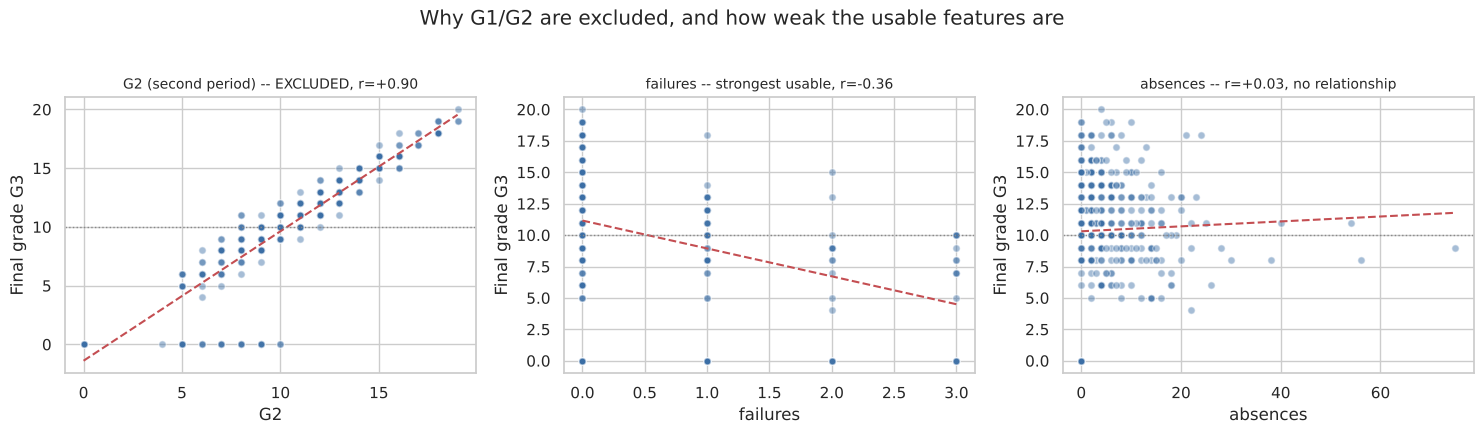

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, (col, label) in zip(axes, [("G2", "G2 (second period) -- EXCLUDED, r=+0.90"),
                                    ("failures", "failures -- strongest usable, r=-0.36"),
                                    ("absences", "absences -- r=+0.03, no relationship")]):
    ax.scatter(df[col], df["G3"], alpha=0.45, s=28, color="#3b6ea5", edgecolor="white")
    if df[col].nunique() > 2:
        m, b = np.polyfit(df[col], df["G3"], 1)
        xs = np.array([df[col].min(), df[col].max()])
        ax.plot(xs, m * xs + b, "r--", lw=1.5)
    ax.axhline(cfg.AT_RISK_THRESHOLD, color="#888", ls=":", lw=1)
    ax.set_xlabel(col); ax.set_ylabel("Final grade G3")
    ax.set_title(label, fontsize=10)

plt.suptitle("Why G1/G2 are excluded, and how weak the usable features are", y=1.03)
plt.tight_layout(); plt.show()

The contrast in that figure is the whole argument for excluding `G1`/`G2`. The
left panel is a tight diagonal band — nearly a straight line. The middle and
right panels, which are what the models actually get, are clouds.

### 4.2 Correlation heatmap

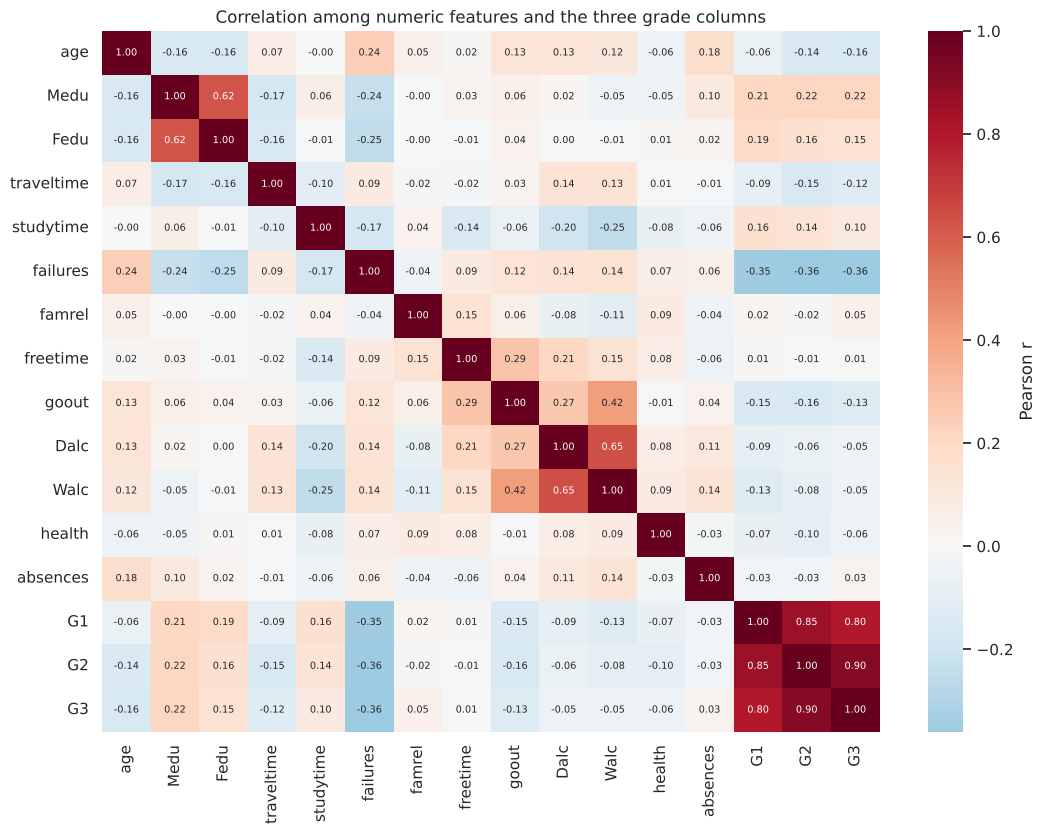

In [15]:
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(df[num_cols].corr(numeric_only=True), cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation among numeric features and the three grade columns")
plt.tight_layout(); plt.show()

Note the bottom-right 3x3 block: `G1`, `G2` and `G3` are tightly
inter-correlated, and almost nothing else correlates strongly with anything.
That block is the leakage, and the rest of the matrix is why the models score
only moderately.

## 5. Final grade across the key features

Box plots rather than scatter plots, because `studytime` and `failures` take
only three or four distinct values — a scatter would show vertical stripes of
overlapping points rather than a distribution.

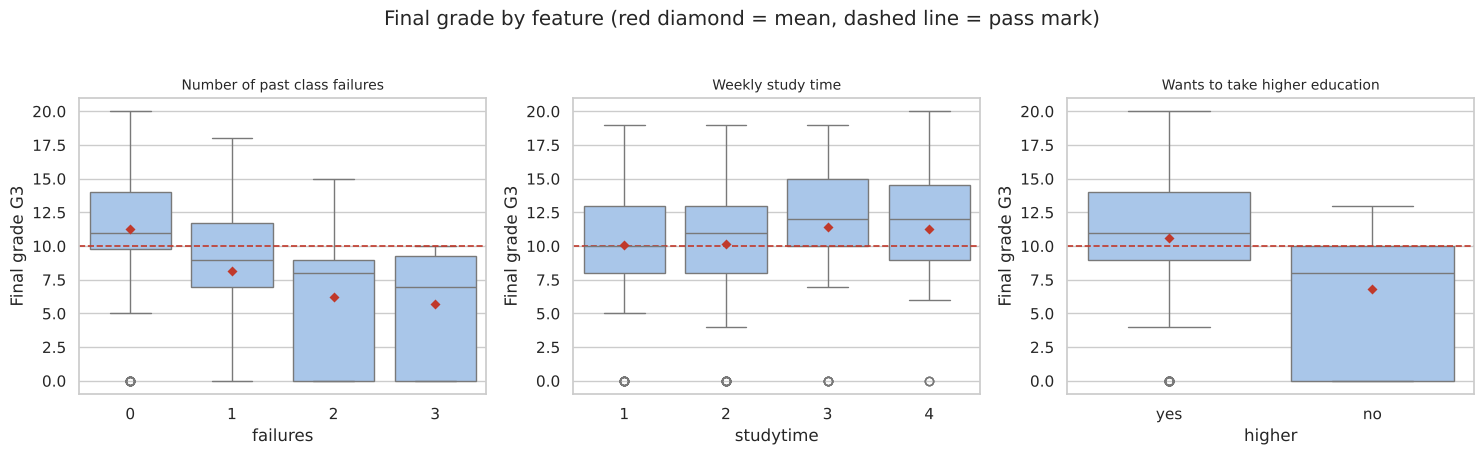

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, col in zip(axes, ["failures", "studytime", "higher"]):
    sns.boxplot(data=df, x=col, y="G3", ax=ax, color="#9ec5f4", showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="#c0392b",
                               markeredgecolor="none", markersize=5))
    ax.axhline(cfg.AT_RISK_THRESHOLD, color="#c0392b", ls="--", lw=1.2)
    ax.set_title(cfg.FEATURE_LABELS.get(col, col), fontsize=10)
    ax.set_ylabel("Final grade G3")
    ax.set_ylim(-1, 21)

plt.suptitle("Final grade by feature (red diamond = mean, dashed line = pass mark)", y=1.03)
plt.tight_layout(); plt.show()

In [17]:
# The same thing numerically, for failures -- the clearest signal in the data.
summary = df.groupby("failures").agg(
    n=("G3", "size"),
    mean_G3=("G3", "mean"),
    median_G3=("G3", "median"),
    pct_at_risk=(cfg.CLASSIFICATION_TARGET, lambda s: s.mean() * 100),
).round(2)
print(summary.to_string())
print()
print("Mean grade falls steadily as past failures rise: "
      + " -> ".join(f"{v:.1f}" for v in summary["mean_G3"]))
print("The at-risk rate rises too, from "
      f"{summary.loc[0, 'pct_at_risk']:.0f}% with no past failures to "
      f"{summary.loc[2, 'pct_at_risk']:.0f}% with two.")
print()
print("Note it is NOT strictly monotonic: the 3-failure group sits at "
      f"{summary.loc[3, 'pct_at_risk']:.0f}%, BELOW the 2-failure group's "
      f"{summary.loc[2, 'pct_at_risk']:.0f}%.")
print(f"With only n={int(summary.loc[2, 'n'])} and n={int(summary.loc[3, 'n'])} "
      "students in those groups, that reversal is well within sampling noise.")
print("This is why `failures` tops every importance ranking -- and also why the")
print("project does not over-interpret the shape of the relationship.")

            n  mean_G3  median_G3  pct_at_risk
failures                                      
0         312    11.25       11.0        25.00
1          50     8.12        9.0        52.00
2          17     6.24        8.0        82.35
3          16     5.69        7.0        75.00

Mean grade falls steadily as past failures rise: 11.2 -> 8.1 -> 6.2 -> 5.7
The at-risk rate rises too, from 25% with no past failures to 82% with two.

Note it is NOT strictly monotonic: the 3-failure group sits at 75%, BELOW the 2-failure group's 82%.
With only n=17 and n=16 students in those groups, that reversal is well within sampling noise.
This is why `failures` tops every importance ranking -- and also why the
project does not over-interpret the shape of the relationship.


## 6. The feature matrix the models actually receive

In [18]:
X, y = dp.split_features_target(df, task="classification")
print(f"X: {X.shape[0]} students x {X.shape[1]} features")
print(f"y: {dict(y.value_counts())}")
print()

forbidden = {"G1", "G2", "G3", "at_risk"}
leaked = forbidden.intersection(X.columns)
print(f"Leakage check -- forbidden columns present in X: {leaked or 'NONE'}")
assert not leaked, "leakage!"
print("(src/data_preprocessing.py enforces this with an assertion, so a training")
print(" run fails loudly rather than producing a quietly inflated score.)")

X: 395 students x 30 features
y: {0: np.int64(265), 1: np.int64(130)}

Leakage check -- forbidden columns present in X: NONE
(src/data_preprocessing.py enforces this with an assertion, so a training
 run fails loudly rather than producing a quietly inflated score.)


In [19]:
pre = dp.build_preprocessor().fit(X)
encoded = dp.get_feature_names(pre)
print(f"{X.shape[1]} input features -> {len(encoded)} columns after encoding\n")
for i in range(0, len(encoded), 5):
    print("  " + ", ".join(encoded[i:i + 5]))

30 input features -> 43 columns after encoding

  age, Medu, Fedu, traveltime, studytime
  failures, famrel, freetime, goout, Dalc
  Walc, health, absences, school_MS, sex_M
  address_U, famsize_LE3, Pstatus_T, Mjob_at_home, Mjob_health
  Mjob_other, Mjob_services, Mjob_teacher, Fjob_at_home, Fjob_health
  Fjob_other, Fjob_services, Fjob_teacher, reason_course, reason_home
  reason_other, reason_reputation, guardian_father, guardian_mother, guardian_other
  schoolsup_yes, famsup_yes, paid_yes, activities_yes, nursery_yes
  higher_yes, internet_yes, romantic_yes


## 7. Summary of what this notebook decided

| Finding | Decision it drove |
|---|---|
| 38 students recorded `G3` = 0, with a gap at 1-3, and most had a non-zero `G1` | **Keep them** (they are the most at-risk group; dropping them to improve R² would be cherry-picking) and document the resulting bimodal target and large residuals |
| `absences` correlates +0.034 with `G3` overall, but **−0.213** once the 38 zero-grade students are excluded | **Report both.** The zero-grade artefact was masking a real negative relationship, which is why the raw correlation must not be quoted alone |
| Majority-class baseline = 67.1% accuracy with recall 0 | **Rank by F1**, use `class_weight="balanced"`, and print the baseline in every comparison table |
| `G1`/`G2` correlate +0.80/+0.90 with `G3` | **Exclude both**, enforce it with an assertion, and measure what the exclusion costs (see the Data Leakage section of the app) |
| Strongest usable correlation is only -0.36 (`failures`) | Expect moderate scores, and **report them honestly** rather than reaching for leakage |
| No high-cardinality categoricals | One-hot encoding is cheap: 17 columns become 30 |
| Ordinal Likert features are ordered scales | **Treat as numeric** (keeps the model small and interpretable), while recording the equal-spacing assumption as a limitation |

**Next step:** `python src/train_models.py`, then `streamlit run app.py`.